[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Daniel-534/Astroestadistica/blob/main/Clases/Clase20260514.ipynb)

Método de transformación inversa.
Pg 287 (311)

**Problema:** Genere $n = 1000$ deviates exponenciales con parámetro de escala $\lambda = 3$ usando el método de transformación inversa descrito en la Sección 7.2 de *Numerical Recipes in C* [[1]], ecuación (7.2.5):

$$
x = -\lambda \cdot \ln(r), \quad r \sim \mathcal{U}(0,1]
$$

Grafique el histograma de las muestras generadas (con `density=True`) y superponga la curva teórica de la función de densidad de probabilidad:

$$
p(x) = \frac{1}{\lambda} e^{-x/\lambda}, \quad x \geq 0
$$

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [10]:
l, n = 3, 1000
np.random.seed(np.random.randint(0,1000)) # Semilla aleatoria
r = np.random.uniform(0,1,n)

expdev = lambda l, r: -l * np.log(r)
samples = expdev(l, r)

x = np.linspace(0, samples.max(), 200)
pdf = (1/l) * np.exp(-x/l)

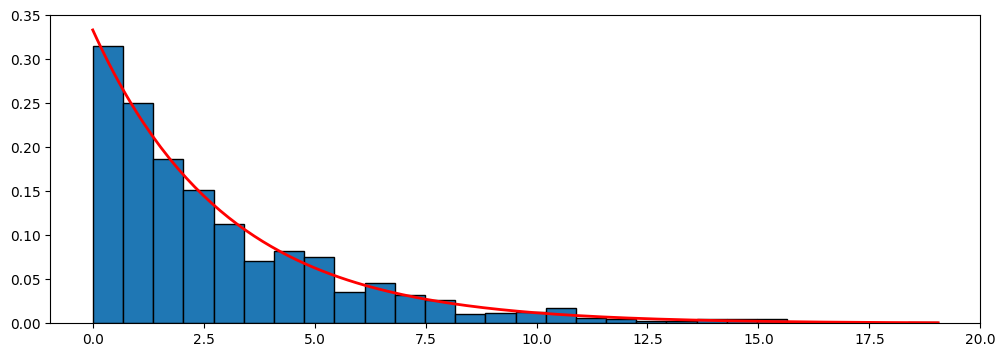

In [11]:
plt.figure(figsize=(6*2,4))
plt.hist(samples, bins='auto', density=True, edgecolor="k")
plt.plot(x, pdf, 'r-', linewidth=2);

1. **Validación estadística básica:** Calcule la media y varianza muestral de los deviates generados y compárelas con los valores teóricos $\mathbb{E}[X] = \lambda$ y $\mathrm{Var}(X) = \lambda^2$.

In [12]:
print(f"Media: {np.mean(samples):.4f} (teórica: {l})")
print(f"Varianza: {np.var(samples):.4f} (teórica: {l**2})")

Media: 2.9198 (teórica: 3)
Varianza: 8.5648 (teórica: 9)


2. **Función de distribución acumulada empírica:** Grafique la ECDF (Empirical Cumulative Distribution Function) de las muestras exponenciales junto con la CDF teórica  (Cumulative Distribution Function) $F(x) = 1 - e^{-x/\lambda}$

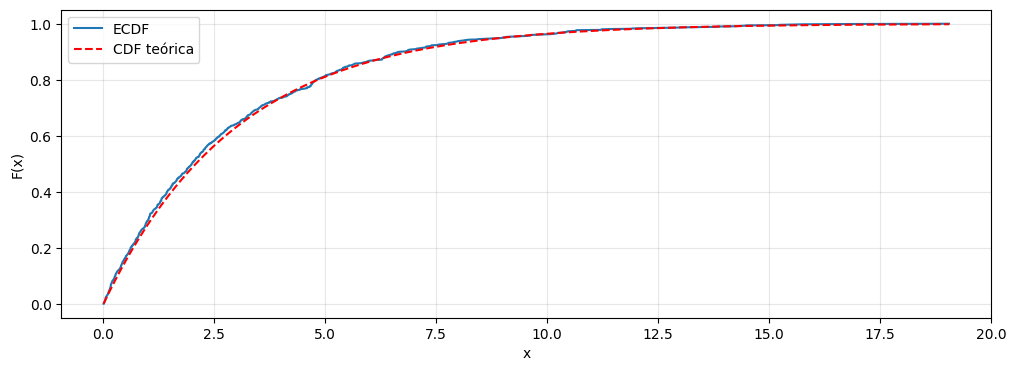

In [13]:
x = np.sort(samples)

ecdf = np.arange(1, n+1) / n
cdf_teo = 1 - np.exp(-x/l)

plt.figure(figsize=(6*2,4))
plt.plot(x, ecdf, label='ECDF')
plt.plot(x, cdf_teo, 'r--', label='CDF teórica')
plt.xlabel('x')
plt.ylabel('F(x)')
plt.legend()
plt.grid(alpha=0.3);

3. **Generación de deviates normales (Box-Muller):** Implemente el método de Box-Muller (ecuación 7.2.10 del libro) para generar pares de deviates normales estándar a partir de uniformes, y grafique un histograma de los resultados superpuesto con $\phi(y) = \frac{1}{\sqrt{2\pi}}e^{-y^2/2}$.


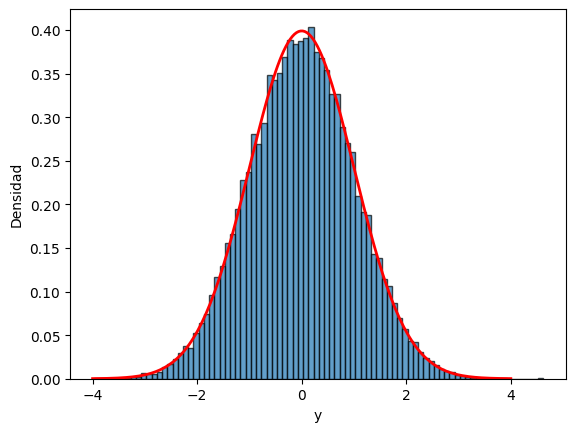

In [16]:
# 3. Box-Muller para normales
n = 10000
np.random.seed(42)
u1, u2 = np.random.uniform(0, 1, n), np.random.uniform(0, 1, n)
y1 = np.sqrt(-2*np.log(u1)) * np.cos(2*np.pi*u2)
y2 = np.sqrt(-2*np.log(u1)) * np.sin(2*np.pi*u2)
samples = np.concatenate([y1, y2])
x = np.linspace(-4, 4, 200)
pdf = norm.pdf(x)
plt.hist(samples, bins='auto', density=True, alpha=0.7, edgecolor='k')
plt.plot(x, pdf, 'r-', linewidth=2); plt.xlabel('y'); plt.ylabel('Densidad');

4. **Efecto del tamaño de muestra:** Repita la generación con $n = 100, 500, 2000$ y grafique en una misma figura los tres histogramas para visualizar la convergencia hacia la PDF teórica.


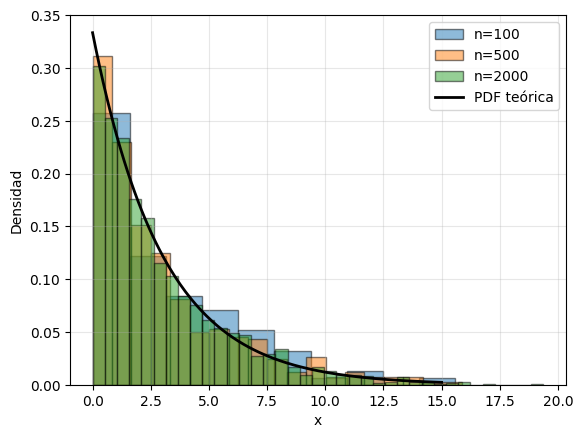

In [17]:
# 4. Efecto del tamaño de muestra
l = 3.0
np.random.seed(42)
for n in [100, 500, 2000]:
    samples = -l * np.log(np.random.uniform(0, 1, n))
    plt.hist(samples, bins='auto', density=True, alpha=0.5, label=f'n={n}', edgecolor='k')

x = np.linspace(0, 15, 200)
plt.plot(x, (1/l)*np.exp(-x/l), 'k-', linewidth=2, label='PDF teórica')
plt.xlabel('x'); plt.ylabel('Densidad'); plt.legend();

5. **Comparación de semillas:** Genere dos conjuntos de muestras con semillas diferentes y calcule la correlación entre sus medias muestrales para verificar independencia.

In [18]:
# 5. Comparación de semillas
l, n = 3.0, 1000
medias = []
for seed in [10, 42, 100, 256, 512]:
    np.random.seed(seed)
    samples = -l * np.log(np.random.uniform(0, 1, n))
    medias.append(np.mean(samples))
medias = np.array(medias)
print(f"Medias muestrales: {medias}")
print(f"Correlación entre medias consecutivas: {np.corrcoef(medias[:-1], medias[1:])[0,1]:.4f}")

Medias muestrales: [3.11587468 3.07917421 2.98018415 3.04074112 2.97566226]
Correlación entre medias consecutivas: 0.1976


**Referencia:**  
[[1]] Press, W. H., et al. (1992). *Numerical Recipes in C*, 2nd ed. Cambridge University Press. Sección 7.2: "Transformation Method: Exponential and Normal Deviates", pp. 287-291.